<a href="https://colab.research.google.com/github/hamzali369/Time-series-anaylsis-with-python/blob/classic-time-series/Auto_regressive_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

FIRST 10 VALUES OF AR PROCESS:

   TimeSeries
0    0.000000
1    0.000000
2    0.000000
3    1.523030
4    0.831968
5   -0.260972
6    1.368352
7    1.996063
8    0.328235
9    0.247569

MODEL PERFORMANCE
Mean Squared Error : 0.9830813618949067
R² Score           : 0.3136501078094466

ESTIMATED AR COEFFICIENTS
Phi_1 : 0.6936563361755379
Phi_2 : -0.4172413385929074
Phi_3 : 0.2034409021699829

Intercept : 0.00045980206521674134


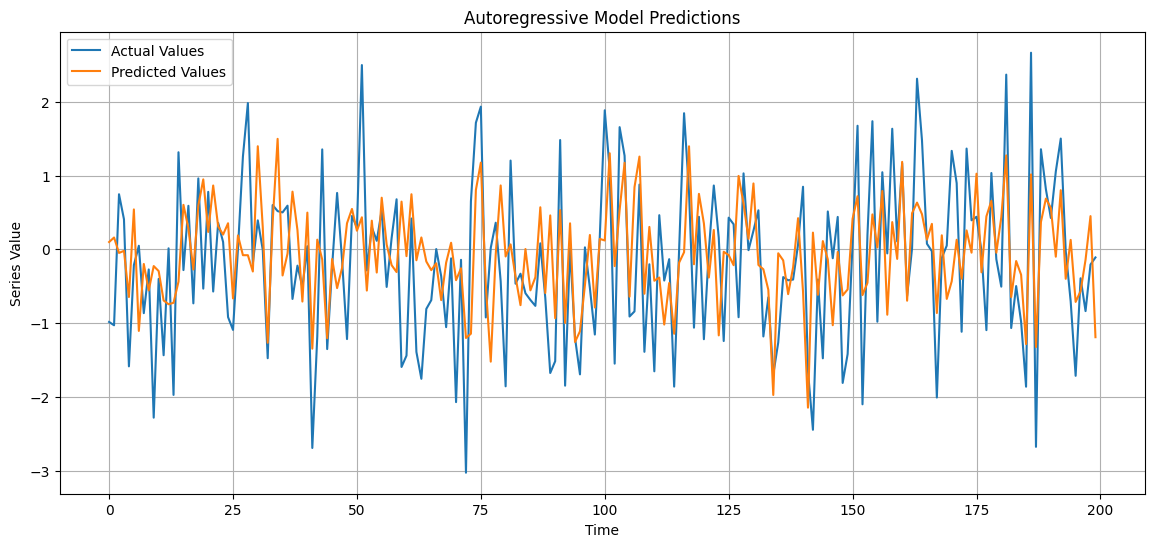

In [1]:
# ============================================================
# AUTOREGRESSIVE MODEL AR(p)
# COMPLETE IMPLEMENTATION WITH LARGE DUMMY DATASET
# ============================================================

# ============================================================
# IMPORT LIBRARIES
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# ============================================================
# STEP 1: SET PARAMETERS
# ============================================================

np.random.seed(42)

# Number of observations
n = 10000

# Order of autoregressive model
p = 3

# AR coefficients
phi = [0.7, -0.4, 0.2]

# White noise standard deviation
sigma = 1

# ============================================================
# STEP 2: GENERATE WHITE NOISE
# ============================================================

# White noise ε_t
noise = np.random.normal(0, sigma, n)

# ============================================================
# STEP 3: GENERATE AR(p) PROCESS
# ============================================================

# Initialize time series with zeros
X = np.zeros(n)

# Generate AR values
#
# AR(3) equation:
#
# X_t = φ1*X_{t-1} + φ2*X_{t-2} + φ3*X_{t-3} + ε_t
#

for t in range(p, n):

    X[t] = (
        phi[0] * X[t-1] +
        phi[1] * X[t-2] +
        phi[2] * X[t-3] +
        noise[t]
    )

# ============================================================
# STEP 4: CREATE DATAFRAME
# ============================================================

data = pd.DataFrame({
    'TimeSeries': X
})

print("FIRST 10 VALUES OF AR PROCESS:\n")
print(data.head(10))

# ============================================================
# STEP 5: CREATE LAG FEATURES
# ============================================================

# Lag variables are previous observations
#
# Example:
# Lag1 = X_{t-1}
# Lag2 = X_{t-2}
# Lag3 = X_{t-3}

for i in range(1, p + 1):
    data[f'Lag_{i}'] = data['TimeSeries'].shift(i)

# Remove missing rows caused by shifting
data.dropna(inplace=True)

# ============================================================
# STEP 6: DEFINE FEATURES & TARGET
# ============================================================

# Independent variables
X_features = data[[f'Lag_{i}' for i in range(1, p + 1)]]

# Dependent variable
y = data['TimeSeries']

# ============================================================
# STEP 7: TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_features,
    y,
    test_size=0.2,
    random_state=42
)

# ============================================================
# STEP 8: TRAIN AUTOREGRESSIVE MODEL
# ============================================================

model = LinearRegression()

model.fit(X_train, y_train)

# ============================================================
# STEP 9: MAKE PREDICTIONS
# ============================================================

y_pred = model.predict(X_test)

# ============================================================
# STEP 10: MODEL EVALUATION
# ============================================================

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n=================================")
print("MODEL PERFORMANCE")
print("=================================")

print("Mean Squared Error :", mse)
print("R² Score           :", r2)

# ============================================================
# STEP 11: DISPLAY MODEL COEFFICIENTS
# ============================================================

print("\n=================================")
print("ESTIMATED AR COEFFICIENTS")
print("=================================")

for i, coef in enumerate(model.coef_):
    print(f"Phi_{i+1} :", coef)

print("\nIntercept :", model.intercept_)

# ============================================================
# STEP 12: VISUALIZATION
# ============================================================

plt.figure(figsize=(14,6))

# Actual values
plt.plot(
    y_test.values[:200],
    label='Actual Values'
)

# Predicted values
plt.plot(
    y_pred[:200],
    label='Predicted Values'
)

plt.title("Autoregressive Model Predictions")
plt.xlabel("Time")
plt.ylabel("Series Value")

plt.legend()
plt.grid()

plt.show()

# ============================================================
# STEP 13: FUTURE FORECASTING
# ============================================================

# Take last p observations
last_values = list(X[-p:])

future_steps = 10

future_predictions = []

# Forecast recursively
for _ in range(future_steps):

    # Convert into array
    input_data = np.array(last_values[::-1]).reshape(1, -1)

    # Predict next value
    next_value = model